# Instalação das Bibliotecas Utilizadas

In [1]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import joblib

# Criação do Banco de dados

In [2]:
conn = sqlite3.connect('../data/hospital.db')

query = "SELECT * FROM pacientes"
df = pd.read_sql(query, conn)

df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


# Limpeza e Preparação de Dados

In [3]:
# Verificar valores nulos
print("Valores nulos:\n", df.isnull().sum())

Valores nulos:
 Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
dtype: int64


In [4]:
# Verificar linhas duplicadas
print("Total de linhas duplicadas: ", df.duplicated().sum())

Total de linhas duplicadas:  24


In [5]:
# Remoção das linhas duplicadas
df = df.drop_duplicates()

In [6]:
# Verificar os tipos dos campos
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2087 non-null   object 
 1   Age             2087 non-null   float64
 2   Height          2087 non-null   float64
 3   Weight          2087 non-null   float64
 4   family_history  2087 non-null   object 
 5   FAVC            2087 non-null   object 
 6   FCVC            2087 non-null   float64
 7   NCP             2087 non-null   float64
 8   CAEC            2087 non-null   object 
 9   SMOKE           2087 non-null   object 
 10  CH2O            2087 non-null   float64
 11  SCC             2087 non-null   object 
 12  FAF             2087 non-null   float64
 13  TUE             2087 non-null   float64
 14  CALC            2087 non-null   object 
 15  MTRANS          2087 non-null   object 
 16  Obesity         2087 non-null   object 
dtypes: float64(8), object(9)
memory usage:

In [7]:
# Arredondando os valores com ruído decimal
cols_ruido = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
df[cols_ruido] = df[cols_ruido].round().astype(int)

In [8]:
for col in df.columns:
    valores_unicos = df[col].unique()
    print(f'{col}: {valores_unicos}')
    print('---')

Gender: ['Female' 'Male']
---
Age: [21.       23.       27.       ... 22.524036 24.361936 23.664709]
---
Height: [1.62     1.52     1.8      ... 1.752206 1.73945  1.738836]
---
Weight: [ 64.        56.        77.       ... 133.689352 133.346641 133.472641]
---
family_history: ['yes' 'no']
---
FAVC: ['no' 'yes']
---
FCVC: [2 3 1]
---
NCP: [3 1 4 2]
---
CAEC: ['Sometimes' 'Frequently' 'Always' 'no']
---
SMOKE: ['no' 'yes']
---
CH2O: [2 3 1]
---
SCC: ['no' 'yes']
---
FAF: [0 3 2 1]
---
TUE: [1 0 2]
---
CALC: ['no' 'Sometimes' 'Frequently' 'Always']
---
MTRANS: ['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike']
---
Obesity: ['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']
---


In [ ]:
# Tradução das colunas
colunas_pt = {
    'Gender': 'genero', 'Age': 'idade', 'Height': 'altura', 'Weight': 'peso',
    'family_history': 'historico_familiar', 'FAVC': 'consumo_alimento_calorico',
    'FCVC': 'freq_consumo_vegetais', 'NCP': 'num_refeicoes', 'CAEC': 'consumo_entre_refeicoes', 'SMOKE': 'fumante',
    'CH2O': 'consumo_agua', 'SCC': 'monitora_caloria', 'FAF': 'freq_atividade_fisica', 'TUE': 'tempo_tela', 'CALC': 'consumo_alcool',
    'MTRANS': 'meio_transporte', 'Obesity': 'diagnostico'
}

df.rename(columns=colunas_pt, inplace=True)

In [10]:
df.columns

Index(['genero', 'idade', 'altura', 'peso', 'historico_familiar',
       'consumo_alimento_calórico', 'freq_consumo_vegetais', 'num_refeicoes',
       'consumo_entre_refeicoes', 'fumante', 'consumo_agua',
       'monitora_caloria', 'freq_atividade_fisica', 'tempo_tela',
       'consumo_alcool', 'meio_transporte', 'diagnostico'],
      dtype='object')

In [ ]:
# Tradução dos valores internos e do target
mapa_valores = {
    'genero': {'Female': 'Feminino', 'Male': 'Masculino'},
    'historico_familiar': {'yes': 'Sim', 'no': 'Não'},
    'consumo_alimento_calorico': {'yes': 'Sim', 'no': 'Não'},
    'fumante': {'yes': 'Sim', 'no': 'Não'},
    'monitora_caloria': {'yes': 'Sim', 'no': 'Não'},
    'consumo_entre_refeicoes': {'no': 'Não consome', 'Sometimes': 'Consome às vezes', 'Frequently': 'Consome frequentemente', 'Always': 'Consome sempre'},
    'consumo_alcool': {'no': 'Não consome', 'Sometimes': 'Consome às vezes', 'Frequently': 'Consome frequentemente', 'Always': 'Consome sempre'},
    'meio_transporte': {'Automobile': 'Carro', 'Motorbike': 'Moto', 'Bike': 'Bicicleta', 'Public_Transportation': 'Transporte público', 'Walking': 'A pé'},
    'diagnostico': {
        'Insufficient_Weight': 'Abaixo do Peso',
        'Normal_Weight': 'Peso Normal',
        'Overweight_Level_I': 'Sobrepeso Nível I',
        'Overweight_Level_II': 'Sobrepeso Nível II',
        'Obesity_Type_I': 'Obesidade Tipo I',
        'Obesity_Type_II': 'Obesidade Tipo II',
        'Obesity_Type_III': 'Obesidade Tipo III'
    },
    # Mapeamento das escalas para o padrão de texto do app no Streamlit
    'consumo_agua': {1: 'Menos de 1 litro por dia', 2: 'De 1 a 2 litros por dia', 3: 'Mais de 2 litros por dia'},
    'freq_atividade_fisica': {0: 'Nenhuma', 1: '1 a 2 vezes por semana', 2: '3 a 4 vezes por semana', 3: '5 ou mais vezes por semana'},
    'tempo_tela': {0: '0 a 2 horas por dia', 1: '3 a 5 horas por dia', 2: 'Mais de 5 horas por dia'},
    'freq_consumo_vegetais': {1: 'Raramente', 2: 'Às vezes', 3: 'Sempre'},
    'num_refeicoes': {
        1: '1 refeição', 
        2: '2 refeições', 
        3: '3 refeições', 
        4: '4 ou mais refeições'
    }
}

df.replace(mapa_valores, inplace=True)

In [12]:
df.head(1)

,genero,idade,altura,peso,historico_familiar,consumo_alimento_calórico,freq_consumo_vegetais,num_refeicoes,consumo_entre_refeicoes,fumante,consumo_agua,monitora_caloria,freq_atividade_fisica,tempo_tela,consumo_alcool,meio_transporte,diagnostico
0,Feminino,21.0,1.62,64.0,Sim,Não,Às vezes,3 refeições,Consome às vezes,Não,De 1 a 2 litros por dia,Não,Nenhuma,3 a 5 horas por dia,Não consome,Transporte público,Peso Normal


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   genero                     2087 non-null   object 
 1   idade                      2087 non-null   float64
 2   altura                     2087 non-null   float64
 3   peso                       2087 non-null   float64
 4   historico_familiar         2087 non-null   object 
 5   consumo_alimento_calórico  2087 non-null   object 
 6   freq_consumo_vegetais      2087 non-null   object 
 7   num_refeicoes              2087 non-null   object 
 8   consumo_entre_refeicoes    2087 non-null   object 
 9   fumante                    2087 non-null   object 
 10  consumo_agua               2087 non-null   object 
 11  monitora_caloria           2087 non-null   object 
 12  freq_atividade_fisica      2087 non-null   object 
 13  tempo_tela                 2087 non-null   object 
 1

Durante o desenvolvimento, percebi que o meio de transporte era a variável de maior peso. Por entender que este é um fator socioeconômico e não necessariamente um hábito de saúde modificável pelo paciente no consultório, decidi removê-lo. Isso forçou o modelo a focar em marcadores biológicos e hábitos de vida, tornando a ferramenta muito mais útil e ética para a prática médica.

In [14]:
df = df.drop('meio_transporte', axis=1)

## Criando uma cópia para exportação (utilizada nos insights)

In [15]:
df_export = df.copy()

if not os.path.exists('../data'):
    os.makedirs('../data')

df_export.to_csv('../data/obesity_cleaned.csv', index=False)

print('Arquivo obesity_cleaned.csv gerado com sucesso!')

Arquivo obesity_cleaned.csv gerado com sucesso!


# Análise Exploratória (EDA)

In [16]:
df.describe()

,idade,altura,peso
count,2087.000000,2087.000000,2087.000000
mean,24.353090,1.702674,86.858730
std,6.368801,0.093186,26.190847
min,14.000000,1.450000,39.000000
25%,19.915937,1.630178,66.000000
50%,22.847618,1.701584,83.101100
75%,26.000000,1.769491,108.015907
max,61.000000,1.980000,173.000000


## Análise da Variável Alvo (Obesity)

C:\Users\dae2ca\AppData\Local\Temp\ipykernel_22080\1429558987.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnostico', palette='magma', order=df['diagnostico'].value_counts().index)


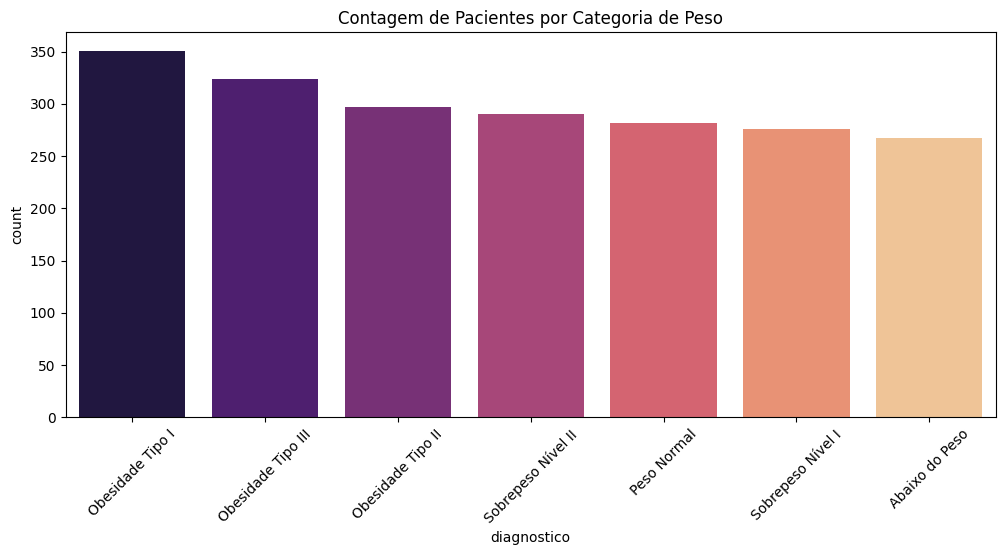

In [17]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='diagnostico', palette='magma', order=df['diagnostico'].value_counts().index)
plt.title('Contagem de Pacientes por Categoria de Peso')
plt.xticks(rotation=45)
plt.show()

* O dataset está relativamente equilibrado

## Perfil Demográfico e Biométrico

Text(0.5, 1.0, 'Distribuição de Idade dos Pacientes')

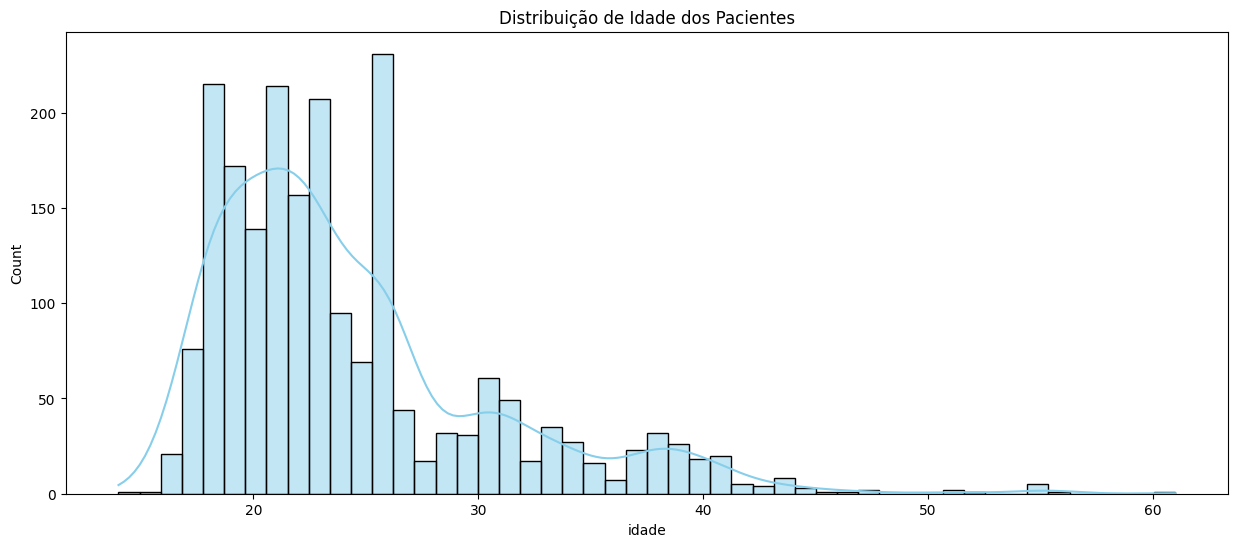

In [18]:
# Distribuição de idade

fig, ax = plt.subplots(figsize=(15, 6))

sns.histplot(df['idade'], kde=True, ax=ax, color='skyblue')
ax.set_title('Distribuição de Idade dos Pacientes')

* Público majoritariamente jovem, com um pico entre 18 e 25 anos.

C:\Users\dae2ca\AppData\Local\Temp\ipykernel_22080\1863230319.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='genero', y='peso', ax=ax, palette='Set2')


Text(0.5, 1.0, 'Distribuição de Peso por Gênero')

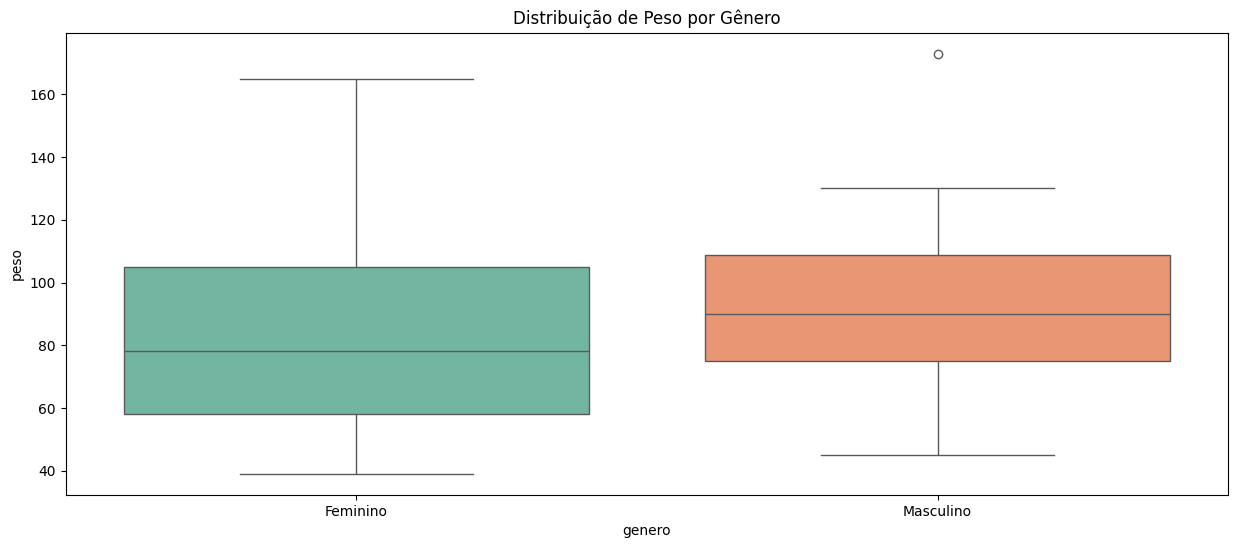

In [19]:
# Boxplot de peso por gênero

fig, ax = plt.subplots(figsize=(15, 6))

sns.boxplot(data=df, x='genero', y='peso', ax=ax, palette='Set2')
ax.set_title('Distribuição de Peso por Gênero')

* Homens tem uma mediana de peso ligeiramente superior às mulheres, mas há um outlier no grupo masculino perto dos 175kg. Precisamos garantir que o modelo lide bem com casos extremos

# Preparação para o Modelo

In [20]:
# Separando as Variáveis
X = df.drop('diagnostico', axis=1)
y = df['diagnostico']

In [21]:
# Dividindo em treino e teste

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')

X_train: (1669, 15)
X_test: (418, 15)


# Pipeline de Pré-Processamento

In [22]:
# Listas de categorias ordinais na ordem correta
ordem_caec_calc = ['Não consome', 'Consome às vezes', 'Consome frequentemente', 'Consome sempre']
ordem_fcvc = ['Raramente', 'Às vezes', 'Sempre']
ordem_ch2o = ['Menos de 1 litro por dia', 'De 1 a 2 litros por dia', 'Mais de 2 litros por dia']
ordem_faf  = ['Nenhuma', '1 a 2 vezes por semana', '3 a 4 vezes por semana', '5 ou mais vezes por semana']
ordem_tue  = ['0 a 2 horas por dia', '3 a 5 horas por dia', 'Mais de 5 horas por dia']
ordem_ncp = ['1 refeição', '2 refeições', '3 refeições', '4 ou mais refeições']

In [ ]:
# Padronização
preprocessor = ColumnTransformer(
    transformers = [
        ('ord_especifico', OrdinalEncoder(categories=[
            ordem_caec_calc, ordem_caec_calc, ordem_fcvc, ordem_ch2o, ordem_faf, ordem_tue, ordem_ncp
        ]), ['consumo_entre_refeicoes', 'consumo_alcool', 'freq_consumo_vegetais', 'consumo_agua', 'freq_atividade_fisica', 'tempo_tela', 'num_refeicoes']),

        ('bin_nom', OrdinalEncoder(), ['genero', 'historico_familiar', 'consumo_alimento_calorico', 'fumante', 'monitora_caloria']),

        ('num', StandardScaler(), ['idade', 'altura', 'peso'])
    ]
)

In [24]:
# Montando a pipeline final (que terá efeito tanto no dataset de treino quanto nos dados vindos do app final)
pipeline_final = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [25]:
# Treinamento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline_final.fit(X_train, y_train)

print('Modelo treinado com sucesso!')

Modelo treinado com sucesso!


In [26]:
# Extraindo os pesos das variáveis
modelo_final = pipeline_final.named_steps['model']
importancias = modelo_final.feature_importances_
nomes_colunas = X_train.columns

df_importancia = pd.DataFrame({
    'Variavel': nomes_colunas,
    'Peso': importancias
}).sort_values(by='Peso', ascending=False)

# Salvar para o app usar
df_importancia.to_csv('../data/features_importance.csv', index=False)

# Avaliação de Performance

## Acurácia

In [27]:
acuracia = pipeline_final.score(X_test, y_test)
print(f'Acurácia global: {acuracia:.2%}')

Acurácia global: 94.98%


## Matriz de Confusão

<Figure size 1000x800 with 0 Axes>

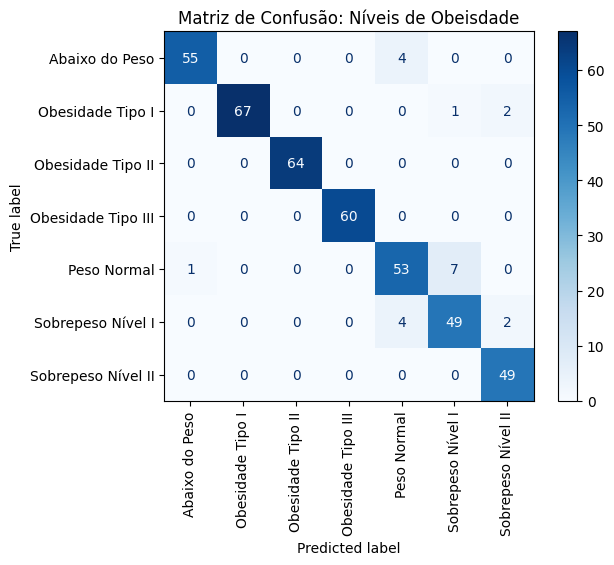

In [28]:
y_pred = pipeline_final.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Matriz de Confusão: Níveis de Obeisdade')
plt.show()

## Classification Report

In [29]:
y_pred = pipeline_final.predict(X_test)

print(classification_report(y_test, y_pred, target_names=np.unique(y_test)))

                    precision    recall  f1-score   support

    Abaixo do Peso       0.98      0.93      0.96        59
  Obesidade Tipo I       1.00      0.96      0.98        70
 Obesidade Tipo II       1.00      1.00      1.00        64
Obesidade Tipo III       1.00      1.00      1.00        60
       Peso Normal       0.87      0.87      0.87        61
 Sobrepeso Nível I       0.86      0.89      0.88        55
Sobrepeso Nível II       0.92      1.00      0.96        49

          accuracy                           0.95       418
         macro avg       0.95      0.95      0.95       418
      weighted avg       0.95      0.95      0.95       418



# Salvando o Modelo

In [30]:
# Criar uma pasta chamada 'models'
if not os.path.exists('../models'):
    os.makedirs('models')

In [31]:
# Salvar o Pipeline completo (pré-processamento + modelo)
joblib.dump(pipeline_final, '../models/modelo_obesidade.pkl')

['../models/modelo_obesidade.pkl']